# Consolidated Results Dashboard

## What this notebook does

It pulls experiment results from CSV files produced by the project notebooks instead of hard-coding values, then builds:

1. Shared baseline training configuration table
2. Trainable-parameter table for all models
3. Tuned-parameter table for all models
4. Clean-data performance table for joint, multitask, and coordinate tasks
5. Robustness tables
6. Stability-training tables
7. Latency tables
8. Dropout-only plots
9. Special-scenario robustness plots
10. Stability-recovery plots
11. A simple deployment-oriented performance-vs-latency view

## Assumptions

This notebook expects CSV outputs to exist somewhere under the project root, typically inside folders such as:

- `notebooks/logs/`
- `logs/`
- `outputs/`

If a section is empty, that is usually not a notebook bug. It means the corresponding experiment notebook did not export a CSV yet.

In [1]:
from __future__ import annotations

import math
import os
import re
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 300)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 120)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.dpi': 300,
})


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for p in candidates:
        if (p / 'src').exists():
            return p
    return cwd


PROJECT_ROOT = find_project_root()
LOG_SEARCH_ROOTS = [
    PROJECT_ROOT / 'notebooks' / 'logs',
    PROJECT_ROOT / 'logs',
    PROJECT_ROOT / 'outputs',
    PROJECT_ROOT,
]
OUTPUT_DIR = PROJECT_ROOT / 'results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('OUTPUT_DIR   =', OUTPUT_DIR)
print('SEARCH ROOTS =')
for p in LOG_SEARCH_ROOTS:
    print('  -', p)

PROJECT_ROOT = /storage/ice1/7/5/kw53/cs7643/final/CS7643-Project
OUTPUT_DIR   = /storage/ice1/7/5/kw53/cs7643/final/CS7643-Project/results
SEARCH ROOTS =
  - /storage/ice1/7/5/kw53/cs7643/final/CS7643-Project/notebooks/logs
  - /storage/ice1/7/5/kw53/cs7643/final/CS7643-Project/logs
  - /storage/ice1/7/5/kw53/cs7643/final/CS7643-Project/outputs
  - /storage/ice1/7/5/kw53/cs7643/final/CS7643-Project


In [12]:
# ---------- CSV discovery / normalization helpers ----------

MODEL_ORDER = ['mlp', 'cnn', 'lstm', 'transformer', 'set_transformer']
MODEL_LABELS = {
    'mlp': 'MLP',
    'cnn': 'CNN',
    'lstm': 'LSTM',
    'transformer': 'Standard Transformer',
    'set_transformer': 'Set Transformer',
}
TASK_ORDER = ['joint', 'multitask', 'coordinate']

def model_label_name(model_family: Optional[str]) -> Optional[str]:
    if model_family is None or (isinstance(model_family, float) and pd.isna(model_family)):
        return None
    return MODEL_LABELS.get(str(model_family), str(model_family))

def normalize_model_family(x: Optional[str]) -> Optional[str]:
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return None
    s = str(x).strip().lower()
    s = s.replace('.pt', '')
    if 'set_transformer' in s or ('set' in s and 'transformer' in s):
        return 'set_transformer'
    if 'transformer' in s:
        return 'transformer'
    if 'cnn' in s:
        return 'cnn'
    if 'lstm' in s:
        return 'lstm'
    if 'mlp' in s:
        return 'mlp'
    return s

def infer_task(x: Optional[str]) -> Optional[str]:
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return None
    s = str(x).strip().lower()
    if 'multitask' in s or ('multi' in s and 'task' in s):
        return 'multitask'
    if 'coordinate' in s or 'coord' in s:
        return 'coordinate'
    if 'joint' in s:
        return 'joint'
    return None

def safe_read_csv(path: Path, nrows: Optional[int] = None) -> pd.DataFrame:
    return pd.read_csv(path, nrows=nrows)

def classify_csv(path: Path, preview_cols: list[str]) -> str:
    name = path.name.lower()
    cols = {c.lower() for c in preview_cols}

    if 'parameter_report' in name or {'model', 'params'}.issubset(cols):
        return 'parameter_report'

    if 'baseline_results' in name:
        return 'baseline_results'

    baseline_metric_cols = {
        'best_epoch', 'building_accuracy', 'floor_accuracy', 'joint_accuracy',
        'coordinate_mean_euclidean', 'coordinate_mean_euclidean_m',
        'coordinate_rmse', 'coordinate_rmse_m', 'score',
    }
    if 'clean' in name and ('model' in cols or 'model_name' in cols) and len(baseline_metric_cols & cols) >= 2:
        return 'baseline_results'

    if 'latency' in name or 'p95_ms' in cols:
        return 'latency'

    if any(tok in name for tok in ['tuning', 'hyperparam', 'hparam', 'optuna', 'best_trials', 'best_params']):
        return 'hyperparameter'

    if 'scenario' in cols or 'regime' in cols or any(tok in name for tok in ['degradation', 'downgradation', 'robust', 'stability']):
        return 'robustness_or_stability'

    return 'other'

def build_csv_index(search_roots: list[Path]) -> pd.DataFrame:
    rows = []
    seen = set()
    for root in search_roots:
        if not root.exists():
            continue
        for path in root.rglob('*.csv'):
            try:
                resolved = path.resolve()
            except Exception:
                resolved = path
            if resolved in seen:
                continue
            seen.add(resolved)
            try:
                preview = safe_read_csv(path, nrows=5)
                cols = list(preview.columns)
            except Exception as e:
                cols = []
                preview = None
                err = str(e)
            else:
                err = None
            rows.append({
                'path': str(path),
                'name': path.name,
                'parent': str(path.parent),
                'kind': classify_csv(path, cols),
                'n_preview_rows': 0 if preview is None else len(preview),
                'columns': ', '.join(cols),
                'read_error': err,
                'size_kb': round(path.stat().st_size / 1024, 2),
            })
    if not rows:
        return pd.DataFrame(columns=['path', 'name', 'parent', 'kind', 'n_preview_rows', 'columns', 'read_error', 'size_kb'])
    return pd.DataFrame(rows).sort_values(['kind', 'name', 'path']).reset_index(drop=True)

csv_index = build_csv_index(LOG_SEARCH_ROOTS)
print(f'Found {len(csv_index)} CSV files.')
#display(csv_index)


Found 86 CSV files.


## 1. Shared baseline training configuration

This table is intentionally explicit because the shared baseline configuration is a protocol choice, not an experiment artifact. It is the common starting point before model-specific tuning.

In [13]:
shared_baseline_cfg = pd.DataFrame([
    ('Optimizer', 'AdamW'),
    ('Learning rate', '2e-3'),
    ('Weight decay', '1e-4'),
    ('Batch size / Val batch size', '256 / 512'),
    ('Train shuffle', 'True'),
    ('Num workers / Pin memory', '0 / False'),
    ('Max epochs / Patience', '200 / 20'),
    ('Print every', '5 epochs'),
    ('Scheduler', 'ReduceLROnPlateau'),
    ('Scheduler factor / patience', '0.5 / 4'),
    ('Scheduler minimum LR', '1e-5'),
    ('Gradient clipping', 'None or model-specific during tuning'),
    ('Logging', 'Enabled (logs/)'),
    ('Run name', 'Auto-generated'),
], columns=['Hyperparameter', 'Value'])

shared_baseline_cfg

,Hyperparameter,Value
0,Optimizer,AdamW
1,Learning rate,2e-3
2,Weight decay,1e-4
3,Batch size / Val batch size,256 / 512
4,Train shuffle,True
5,Num workers / Pin memory,0 / False
6,Max epochs / Patience,200 / 20
7,Print every,5 epochs
8,Scheduler,ReduceLROnPlateau
9,Scheduler factor / patience,0.5 / 4


## 2. Number of trainable parameters for all models

In [14]:
ALLOWED_PARAMETER_FILES = {
    "mlp_parameter_report.csv",
    "cnn_lstm_parameter_report.csv",
    "transformer_parameter_report.csv",
}

def standardize_parameter_report(df: pd.DataFrame, source: Path) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]

    if "model_name" in out.columns and "model" not in out.columns:
        out["model"] = out["model_name"]

    if "params_millions" not in out.columns and "params" in out.columns:
        out["params_millions"] = (
            pd.to_numeric(out["params"], errors="coerce") / 1_000_000
        )

    if "model" in out.columns:
        out["model_family"] = out["model"].map(normalize_model_family)
        out["task"] = out["model"].map(infer_task)
        out["model_label"] = out["model_family"].map(model_label_name)
    else:
        out["model_family"] = pd.Series(index=out.index, dtype="object")
        out["task"] = pd.Series(index=out.index, dtype="object")
        out["model_label"] = pd.Series(index=out.index, dtype="object")

    out["source_file"] = source.name

    cols = [
        c for c in [
            "model_label", "task", "model", "model_family",
            "params", "params_millions", "source_file"
        ]
        if c in out.columns
    ]
    out = out[cols].copy()

    if "model" in out.columns:
        out = out[
            ~out["model"].astype(str).str.contains("reference", case=False, na=False)
        ]

    # One row per model/task. If duplicate rows still exist, keep the first.
    dedup_cols = [c for c in ["model", "task"] if c in out.columns]
    if dedup_cols:
        out = out.drop_duplicates(subset=dedup_cols, keep="first")

    sort_cols = [c for c in ["model_label", "task", "model"] if c in out.columns]
    if sort_cols:
        out = out.sort_values(sort_cols).reset_index(drop=True)

    return out


parameter_frames = []

# Do not rely on csv kind classification here.
# Read only the approved parameter-report files from csv_index.
for _, row in csv_index.iterrows():
    path = Path(row["path"])
    if path.name in ALLOWED_PARAMETER_FILES:
        try:
            parameter_frames.append(
                standardize_parameter_report(pd.read_csv(path), path)
            )
        except Exception as e:
            print(f"[skip parameter] {path.name}: {e}")

parameter_table = (
    pd.concat(parameter_frames, ignore_index=True)
    if parameter_frames
    else pd.DataFrame()
)

if parameter_table.empty:
    print("No approved parameter-report CSVs were found.")
else:
    display(parameter_table)


,model_label,task,model,model_family,params,params_millions,source_file
0,CNN,coordinate,cnn_coordinate,cnn,1582082,1.582082,cnn_lstm_parameter_report.csv
1,CNN,joint,cnn_joint,cnn,1584909,1.584909,cnn_lstm_parameter_report.csv
2,CNN,multitask,cnn_multitask,cnn,1583624,1.583624,cnn_lstm_parameter_report.csv
3,LSTM,coordinate,lstm_coordinate,lstm,1639203,1.639203,cnn_lstm_parameter_report.csv
4,LSTM,joint,lstm_joint,lstm,1642030,1.642030,cnn_lstm_parameter_report.csv
5,LSTM,multitask,lstm_multitask,lstm,1640745,1.640745,cnn_lstm_parameter_report.csv
6,MLP,coordinate,mlp_coordinate,mlp,1726210,1.726210,mlp_parameter_report.csv
7,MLP,joint,mlp_joint,mlp,1729037,1.729037,mlp_parameter_report.csv
8,MLP,multitask,mlp_multitask,mlp,1727752,1.727752,mlp_parameter_report.csv
9,Set Transformer,coordinate,set_transformer_coordinate,set_transformer,481794,0.481794,transformer_parameter_report.csv


## 3. Tuned parameters for all models

This section is deliberately CSV-driven. It does **not** hardcode final tuned values. If it is empty, the tuning notebooks still need to export a summary CSV.

In [10]:
COMMON_PARAM_COLS = [
    'model', 'model_family', 'family', 'task',
    'lr', 'learning_rate', 'weight_decay', 'dropout',
    'd_model', 'nhead', 'num_heads', 'num_layers', 'num_sab_layers',
    'dim_feedforward', 'num_seed_vectors',
    'hidden_dim', 'hidden_dims', 'channels', 'kernel_size',
    'lstm_hidden_dim', 'num_lstm_layers', 'bidirectional',
    'max_epochs', 'patience', 'grad_clip_norm',
    'score', 'best_score', 'val_score', 'eval_loss', 'val_loss', 'objective'
]

def standardize_tuning_df(df: pd.DataFrame, source: Path) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]

    if 'model_name' in out.columns and 'model' not in out.columns:
        out['model'] = out['model_name']
    if 'architecture' in out.columns and 'model_family' not in out.columns:
        out['model_family'] = out['architecture']
    if 'family' in out.columns and 'model_family' not in out.columns:
        out['model_family'] = out['family']
    if 'model' in out.columns and 'task' not in out.columns:
        out['task'] = out['model'].map(infer_task)
    if 'model_family' not in out.columns and 'model' in out.columns:
        out['model_family'] = out['model'].map(normalize_model_family)

    keep = [c for c in COMMON_PARAM_COLS if c in out.columns]
    if keep:
        out = out[keep].copy()

    score_priority = ['best_score', 'score', 'val_score', 'objective']
    loss_priority = ['eval_loss', 'val_loss']
    group_cols = [c for c in ['model', 'model_family', 'task'] if c in out.columns]

    if group_cols and len(out) > 0:
        sort_col = None
        ascending = False
        for c in score_priority:
            if c in out.columns:
                sort_col = c
                ascending = False
                break
        if sort_col is None:
            for c in loss_priority:
                if c in out.columns:
                    sort_col = c
                    ascending = True
                    break

        if sort_col is not None:
            out[sort_col] = pd.to_numeric(out[sort_col], errors='coerce')
            out = out.sort_values(
                group_cols + [sort_col],
                ascending=[True] * len(group_cols) + [ascending]
            )
            out = out.groupby(group_cols, as_index=False).first()
        else:
            out = out.groupby(group_cols, as_index=False).first()

    if 'model_family' in out.columns:
        out['model_family'] = out['model_family'].map(normalize_model_family)
        out['model_label'] = out['model_family'].map(model_label_name)

    out['source_file'] = source.name

    front = [c for c in ['model_label', 'task', 'model', 'model_family'] if c in out.columns]
    other = [c for c in out.columns if c not in front + ['source_file']]
    out = out[front + other + ['source_file']]

    return out

ALLOWED_TUNING_FILES = {
    'mlp_tuning_grid_results.csv',
    'cnn_lstm_tuning_grid_results.csv',
    'transformer_tuning_grid_results.csv',
}

tuning_candidates = []
for _, row in csv_index.iterrows():
    path = Path(row['path'])
    if path.name in ALLOWED_TUNING_FILES:
        try:
            tuning_candidates.append((path, pd.read_csv(path)))
        except Exception as e:
            print(f'[skip tuning] {path.name}: {e}')

tuned_param_frames = [standardize_tuning_df(df, path) for path, df in tuning_candidates]
tuned_param_frames = [df for df in tuned_param_frames if len(df.columns) > 3 and not df.empty]
tuned_params_table = pd.concat(tuned_param_frames, ignore_index=True) if tuned_param_frames else pd.DataFrame()

if tuned_params_table.empty:
    print('No tuning-summary CSVs were found. Export best-trial tables from the tuning notebooks first.')
else:
    display(tuned_params_table)

,model_label,task,model_family,family,lr,weight_decay,max_epochs,patience,grad_clip_norm,score,val_loss,source_file,dropout,d_model,nhead,num_heads,num_layers,num_sab_layers,dim_feedforward,num_seed_vectors
0,CNN,coordinate,cnn,cnn,0.0005,0.0001,60,12,NaN,-40.884560,0.183814,cnn_lstm_tuning_grid_results.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CNN,joint,cnn,cnn,0.0010,0.0005,50,10,NaN,0.840684,0.928447,cnn_lstm_tuning_grid_results.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CNN,multitask,cnn,cnn,0.0010,0.0001,50,10,NaN,0.826283,1.240370,cnn_lstm_tuning_grid_results.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LSTM,coordinate,lstm,lstm,0.0010,0.0001,50,10,1.0,-10.574129,0.014667,cnn_lstm_tuning_grid_results.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LSTM,joint,lstm,lstm,0.0005,0.0005,80,15,1.0,0.953195,0.259721,cnn_lstm_tuning_grid_results.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,LSTM,multitask,lstm,lstm,0.0005,0.0001,60,12,1.0,0.951395,0.337477,cnn_lstm_tuning_grid_results.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,MLP,coordinate,mlp,mlp,0.0005,0.0005,80,15,NaN,-9.793972,0.010967,mlp_tuning_grid_results.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,MLP,joint,mlp,mlp,0.0010,0.0005,50,10,NaN,0.907291,0.419937,mlp_tuning_grid_results.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,MLP,multitask,mlp,mlp,0.0010,0.0005,50,10,NaN,0.909091,0.564936,mlp_tuning_grid_results.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,set,coordinate,set,set,0.0010,0.0005,50,10,1.0,-10.919728,0.013415,transformer_tuning_grid_results.csv,0.1,128.0,NaN,4.0,NaN,2.0,256.0,1.0


## 4. Performance on clean data

In [11]:
BASELINE_KEEP_COLS = [
    'model', 'task', 'best_epoch',
    'building_accuracy', 'floor_accuracy', 'joint_accuracy',
    'coordinate_mean_euclidean', 'coordinate_mean_euclidean_m',
    'coordinate_rmse', 'coordinate_rmse_m',
    'score', 'eval_loss', 'val_loss'
]

ALLOWED_BASELINE_FILES = {
    'mlp_baseline_results.csv',
    'cnn_lstm_baseline_results.csv',
    'transformer_baseline_results.csv',
}

FAIR_BASELINE_DIR = PROJECT_ROOT / 'notebooks' / 'logs' / 'fair_baseline'

def standardize_baseline_df(df: pd.DataFrame, source: Path) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]

    if 'model_name' in out.columns and 'model' not in out.columns:
        out['model'] = out['model_name']

    if 'model' in out.columns and 'task' not in out.columns:
        out['task'] = out['model'].map(infer_task)

    if 'model' in out.columns:
        out['model_family'] = out['model'].map(normalize_model_family)
        out['model_label'] = out['model_family'].map(model_label_name)

    out['source_file'] = source.name

    front = [c for c in ['model_label', 'task', 'model', 'model_family'] if c in out.columns]
    keep = [c for c in BASELINE_KEEP_COLS if c in out.columns]

    ordered_cols = []
    for c in front + keep + ['source_file']:
        if c not in ordered_cols:
            ordered_cols.append(c)

    out = out[ordered_cols].copy()

    sort_cols = [c for c in ['model_label', 'task', 'model'] if c in out.columns]
    if sort_cols:
        out = out.sort_values(sort_cols).reset_index(drop=True)

    return out

print("Looking in:", FAIR_BASELINE_DIR)

baseline_frames = []
found_files = []

if FAIR_BASELINE_DIR.exists():
    for path in sorted(FAIR_BASELINE_DIR.glob('*.csv')):
        if path.name in ALLOWED_BASELINE_FILES:
            found_files.append(path.name)
            try:
                df = pd.read_csv(path)
                baseline_frames.append(standardize_baseline_df(df, path))
            except Exception as e:
                print(f'[skip] {path.name}: {e}')
else:
    print("Directory does not exist:", FAIR_BASELINE_DIR)

print("Found approved baseline files:", found_files)

clean_table = pd.concat(baseline_frames, ignore_index=True) if baseline_frames else pd.DataFrame()

if clean_table.empty:
    print('No approved baseline-results CSVs were found in notebooks/logs/fair_baseline.')
else:
    display(clean_table)

Looking in: /storage/ice1/7/5/kw53/cs7643/final/CS7643-Project/notebooks/logs/fair_baseline
Found approved baseline files: ['cnn_lstm_baseline_results.csv', 'mlp_baseline_results.csv', 'transformer_baseline_results.csv']


,model_label,task,model,model_family,best_epoch,building_accuracy,floor_accuracy,joint_accuracy,coordinate_mean_euclidean,coordinate_mean_euclidean_m,coordinate_rmse,coordinate_rmse_m,score,val_loss,source_file
0,CNN,coordinate,cnn_coordinate,cnn,56,NaN,NaN,NaN,0.449747,42.952327,0.618230,60.193217,-42.952327,0.192431,cnn_lstm_baseline_results.csv
1,CNN,joint,cnn_joint,cnn,22,0.944194,0.842484,0.832583,NaN,NaN,NaN,NaN,0.832583,0.826921,cnn_lstm_baseline_results.csv
2,CNN,multitask,cnn_multitask,cnn,25,0.971197,0.818182,0.807381,NaN,NaN,NaN,NaN,0.807381,1.052368,cnn_lstm_baseline_results.csv
3,LSTM,coordinate,lstm_coordinate,lstm,43,NaN,NaN,NaN,0.128587,11.399431,0.177738,15.571116,-11.399431,0.015807,cnn_lstm_baseline_results.csv
4,LSTM,joint,lstm_joint,lstm,22,0.995500,0.947795,0.947795,NaN,NaN,NaN,NaN,0.947795,0.370300,cnn_lstm_baseline_results.csv
5,LSTM,multitask,lstm_multitask,lstm,18,0.990099,0.950495,0.941494,NaN,NaN,NaN,NaN,0.941494,0.377392,cnn_lstm_baseline_results.csv
6,MLP,coordinate,mlp_coordinate,mlp,55,NaN,NaN,NaN,0.110609,9.767193,0.148603,13.066840,-9.767193,0.011274,mlp_baseline_results.csv
7,MLP,joint,mlp_joint,mlp,22,0.995500,0.909091,0.908191,NaN,NaN,NaN,NaN,0.908191,0.594379,mlp_baseline_results.csv
8,MLP,multitask,mlp_multitask,mlp,11,0.997300,0.910891,0.910891,NaN,NaN,NaN,NaN,0.910891,0.404846,mlp_baseline_results.csv
9,Set Transformer,coordinate,set_transformer_coordinate,set_transformer,44,NaN,NaN,NaN,0.112004,9.764674,0.149488,12.678125,-9.764674,0.011353,transformer_baseline_results.csv


## 5–6. Robustness and stability results

This notebook expects robustness outputs in long format when possible, with columns like:

- `regime` (`clean_train` or `aug_train`)
- `scenario`
- `model`
- `task`
- a metric column such as `metric_value`, `score`, or `coordinate_mean_euclidean`

It also tries to handle a common wide-format fallback by melting model/task columns.

In [54]:
SPECIAL_SCENARIOS = [
    'bias5_only',
    'noise3_only',
    'drop0.15_bias6_noise0',
    'drop0.25_bias3_noise1',
    'drop0.35_bias4_noise2',
    'drop0.40_bias5_noise3',
]

# Keep one primary metric per task for reader-facing plots.
TASK_PRIMARY_METRIC = {
    'joint': 'joint_accuracy',
    'multitask': 'joint_accuracy',
    'coordinate': 'coordinate_mean_euclidean_m',
}

CLASS_PRIMARY_CANDIDATES = ['joint_accuracy', 'score', 'accuracy', 'metric_value', 'value']
COORD_PRIMARY_CANDIDATES = ['coordinate_mean_euclidean_m', 'coordinate_mean_euclidean', 'metric_value', 'value']
DERIVED_RESULT_TOKENS = ['delta', 'pivot', 'retained', 'recovered', 'deployability', 'machine_spec', 'latency', 'parameter', 'tuning', 'optuna']

def canonical_metric_key(task: Optional[str], metric_name: Optional[str]) -> Optional[str]:
    task = None if task is None else str(task).lower()
    metric_name = '' if metric_name is None else str(metric_name).lower()

    if task == 'coordinate':
        if any(tok in metric_name for tok in ['coordinate_mean_euclidean_m', 'coordinate_mean_euclidean', 'metric_value', 'value']):
            return 'coordinate_mean_euclidean_m'
        return None

    if task in {'joint', 'multitask'}:
        if any(tok in metric_name for tok in ['joint_accuracy', 'score', 'accuracy', 'metric_value', 'value']):
            return 'joint_accuracy'
        return None

    return None

def infer_regime_from_source(path: Path) -> Optional[str]:
    s = path.name.lower()
    if 'aug' in s or 'stability' in s:
        return 'aug_train'
    if 'clean' in s or 'robust' in s or 'degradation' in s or 'downgradation' in s:
        return 'clean_train'
    return None

def parse_model_task_token(token: str) -> tuple[Optional[str], Optional[str]]:
    token = str(token).strip().lower()
    return normalize_model_family(token), infer_task(token)

def standardize_regime_value(x: Optional[str]) -> Optional[str]:
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return 'clean_train'
    s = str(x).strip().lower()
    if s in {'clean_train', 'clean', 'baseline', 'clean_only', 'none'}:
        return 'clean_train'
    if s in {'aug_train', 'stability', 'stability_train', 'augmented', 'aug'}:
        return 'aug_train'
    return s

def _pick_primary_metric_for_row(row: pd.Series, columns: list[str]) -> tuple[Optional[str], Optional[float]]:
    task = row.get('task')
    if task == 'coordinate':
        for c in COORD_PRIMARY_CANDIDATES:
            if c in columns and pd.notna(row.get(c)):
                return 'coordinate_mean_euclidean_m', row.get(c)
        return None, None

    if task in {'joint', 'multitask'}:
        for c in CLASS_PRIMARY_CANDIDATES:
            if c in columns and pd.notna(row.get(c)):
                return 'joint_accuracy', row.get(c)
        return None, None

    return None, None

def standardize_robustness_df(df: pd.DataFrame, source: Path) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    cols = list(out.columns)

    # Case 1: long-format table with scenario + model.
    if {'scenario', 'model'}.issubset(out.columns):
        if 'task' not in out.columns:
            out['task'] = out['model'].map(infer_task)
        if 'regime' not in out.columns:
            out['regime'] = infer_regime_from_source(source)

        if 'metric' in out.columns and 'metric_value' in out.columns:
            long_df = out.copy()
            long_df['metric'] = long_df.apply(lambda r: canonical_metric_key(r.get('task'), r.get('metric')), axis=1)
        else:
            long_df = out.copy()
            picked = long_df.apply(lambda r: _pick_primary_metric_for_row(r, cols), axis=1)
            long_df['metric'] = picked.map(lambda x: x[0] if isinstance(x, tuple) else None)
            long_df['metric_value'] = picked.map(lambda x: x[1] if isinstance(x, tuple) else None)

        long_df['model_family'] = long_df['model'].map(normalize_model_family)
        long_df['model_label'] = long_df['model_family'].map(model_label_name)
        long_df['regime'] = long_df['regime'].map(standardize_regime_value).fillna('clean_train')
        long_df['source_file'] = source.name

        keep = [
            'regime', 'scenario', 'model_label', 'model_family',
            'model', 'task', 'metric', 'metric_value', 'source_file'
        ]
        long_df = long_df[[c for c in keep if c in long_df.columns]].copy()
        long_df = long_df[long_df['task'].notna() & long_df['metric'].notna()]
        return long_df

    # Case 2: wide-format table with scenario + model_task columns.
    if 'scenario' in out.columns:
        id_vars = [c for c in out.columns if c in {'scenario', 'regime', 'train_regime', 'seed'}]
        value_vars = [c for c in out.columns if c not in id_vars]

        melted = out.melt(
            id_vars=id_vars,
            value_vars=value_vars,
            var_name='model_token',
            value_name='metric_value'
        )
        melted['model_family'] = melted['model_token'].map(lambda x: parse_model_task_token(x)[0])
        melted['task'] = melted['model_token'].map(lambda x: parse_model_task_token(x)[1])
        melted['model'] = melted['model_token']

        if 'regime' not in melted.columns:
            if 'train_regime' in melted.columns:
                melted['regime'] = melted['train_regime']
            else:
                melted['regime'] = infer_regime_from_source(source)

        melted['regime'] = melted['regime'].map(standardize_regime_value).fillna('clean_train')
        melted['model_label'] = melted['model_family'].map(model_label_name)
        melted['metric'] = melted['task'].map(TASK_PRIMARY_METRIC)
        melted['source_file'] = source.name

        keep = [
            'regime', 'scenario', 'model_label', 'model_family',
            'model', 'task', 'metric', 'metric_value', 'source_file'
        ]
        melted = melted[[c for c in keep if c in melted.columns]].copy()
        melted = melted[melted['task'].notna() & melted['metric'].notna()]
        return melted

    return pd.DataFrame()

robust_candidates = []
for _, row in csv_index.iterrows():
    path = Path(row['path'])
    name = path.name.lower()
    cols = {c.strip().lower() for c in str(row.get('columns', '')).split(',') if c.strip()}

    if any(tok in name for tok in DERIVED_RESULT_TOKENS):
        continue

    looks_like_robustness = (
        'scenario' in cols
        and any(tok in name for tok in ['clean', 'aug', 'robust', 'stability', 'degradation', 'downgradation', 'result'])
    )
    if row['kind'] == 'robustness_or_stability' or looks_like_robustness:
        try:
            robust_candidates.append((path, pd.read_csv(path)))
        except Exception as e:
            print(f'[skip robustness] {path.name}: {e}')

robust_frames = [standardize_robustness_df(df, path) for path, df in robust_candidates]
robust_frames = [df for df in robust_frames if not df.empty]

robustness_long = pd.concat(
    robust_frames, ignore_index=True
) if robust_frames else pd.DataFrame(
    columns=['regime', 'scenario', 'model_label', 'model_family', 'model', 'task', 'metric', 'metric_value', 'source_file']
)

if robustness_long.empty:
    print('No robustness/stability CSVs were found.')
else:
    robustness_long['metric_value'] = pd.to_numeric(robustness_long['metric_value'], errors='coerce')
    robustness_long['regime'] = robustness_long['regime'].fillna('clean_train')
    robustness_long = robustness_long.dropna(subset=['metric_value', 'model', 'task', 'metric'])

    # Collapse duplicate exports robustly. Median protects against accidental bad duplicate rows.
    robustness_long = (
        robustness_long
        .groupby(['regime', 'scenario', 'model_label', 'model_family', 'model', 'task', 'metric'], as_index=False)
        .agg(
            metric_value=('metric_value', 'median'),
            source_file=('source_file', lambda s: '|'.join(sorted(set(map(str, s)))))
        )
        .sort_values(['regime', 'task', 'scenario', 'model_label'])
        .reset_index(drop=True)
    )

    print('Loaded long-format rows:', len(robustness_long))
    display(robustness_long.head(20))


Loaded long-format rows: 540


,regime,scenario,model_label,model_family,model,task,metric,metric_value,source_file
0,aug_train,bias5_only,CNN,cnn,cnn_coordinate,coordinate,coordinate_mean_euclidean_m,43.155027,results_aug.csv|table_robustness_stability_long.csv
1,aug_train,bias5_only,LSTM,lstm,lstm_coordinate,coordinate,coordinate_mean_euclidean_m,10.804344,results_aug.csv|table_robustness_stability_long.csv
2,aug_train,bias5_only,MLP,mlp,mlp_coordinate,coordinate,coordinate_mean_euclidean_m,8.424780,results_aug.csv|table_robustness_stability_long.csv
3,aug_train,bias5_only,Set Transformer,set_transformer,set_transformer_coordinate,coordinate,coordinate_mean_euclidean_m,13.014576,results_aug.csv|table_robustness_stability_long.csv
4,aug_train,bias5_only,Standard Transformer,transformer,transformer_coordinate,coordinate,coordinate_mean_euclidean_m,9.259114,results_aug.csv|table_robustness_stability_long.csv
5,aug_train,clean,CNN,cnn,cnn_coordinate,coordinate,coordinate_mean_euclidean_m,43.498993,results_aug.csv|table_robustness_stability_long.csv
6,aug_train,clean,LSTM,lstm,lstm_coordinate,coordinate,coordinate_mean_euclidean_m,10.346942,results_aug.csv|table_robustness_stability_long.csv
7,aug_train,clean,MLP,mlp,mlp_coordinate,coordinate,coordinate_mean_euclidean_m,8.554965,results_aug.csv|table_robustness_stability_long.csv
8,aug_train,clean,Set Transformer,set_transformer,set_transformer_coordinate,coordinate,coordinate_mean_euclidean_m,13.468526,results_aug.csv|table_robustness_stability_long.csv
9,aug_train,clean,Standard Transformer,transformer,transformer_coordinate,coordinate,coordinate_mean_euclidean_m,9.040032,results_aug.csv|table_robustness_stability_long.csv


In [55]:
def ordered_model_labels(existing):
    preferred = [MODEL_LABELS[m] for m in MODEL_ORDER]
    return [m for m in preferred if m in list(existing)]

def pivot_metric_table(df: pd.DataFrame, regime: str, task: str) -> pd.DataFrame:
    sub = df[(df['regime'] == regime) & (df['task'] == task)].copy()
    if sub.empty:
        return pd.DataFrame()
    pivot = sub.pivot_table(index='scenario', columns='model_label', values='metric_value', aggfunc='first')
    pivot = pivot.reindex(columns=ordered_model_labels(pivot.columns))
    return pivot

if robustness_long.empty:
    print('No robustness/stability tables to display.')
else:
    print('### Robustness tables (trained on clean, evaluated under degradation)')
    for task in TASK_ORDER:
        tbl = pivot_metric_table(robustness_long, 'clean_train', task)
        if not tbl.empty:
            print(f'Task: {task}')
            display(tbl)

    print('### Stability tables (trained with augmentation / stability training)')
    for task in TASK_ORDER:
        tbl = pivot_metric_table(robustness_long, 'aug_train', task)
        if not tbl.empty:
            print(f'Task: {task}')
            display(tbl)


### Robustness tables (trained on clean, evaluated under degradation)
Task: joint


model_label,MLP,CNN,LSTM,Standard Transformer,Set Transformer
scenario,,,,,
bias5_only,0.878854,0.793176,0.914154,0.921242,0.900512
clean,0.879388,0.808056,0.917557,0.913901,0.909794
drop0.15_bias6_noise0,0.842119,0.628797,0.884338,0.902312,0.885464
drop0.25_bias3_noise1,0.800939,0.520927,0.852695,0.873481,0.863271
drop0.35_bias4_noise2,0.744628,0.381807,0.810812,0.844931,0.849966
drop0.40_bias5_noise3,0.714362,0.312106,0.768874,0.812078,0.805271
dropout_0.05,0.869093,0.747469,0.903240,0.906194,0.905491
dropout_0.10,0.837674,0.690313,0.881076,0.900934,0.894211
dropout_0.15,0.812191,0.605873,0.867574,0.895618,0.887095


Task: multitask


model_label,MLP,CNN,LSTM,Standard Transformer,Set Transformer
scenario,,,,,
bias5_only,0.873650,0.764514,0.921580,0.924421,0.900062
clean,0.876772,0.800996,0.925096,0.925264,0.905237
drop0.15_bias6_noise0,0.840965,0.591275,0.874662,0.906334,0.886054
drop0.25_bias3_noise1,0.794864,0.476457,0.817450,0.889852,0.857195
drop0.35_bias4_noise2,0.724516,0.352751,0.783978,0.860655,0.823498
drop0.40_bias5_noise3,0.692957,0.291179,0.718187,0.817479,0.786369
dropout_0.05,0.866449,0.722660,0.909878,0.921833,0.894239
dropout_0.10,0.834833,0.675208,0.890892,0.903803,0.881104
dropout_0.15,0.824032,0.592090,0.862117,0.892524,0.870865


Task: coordinate


...

model_label,MLP,CNN,LSTM,Standard Transformer,Set Transformer
scenario,,,,,
bias5_only,0.931593,0.836184,0.954095,0.937894,0.949595
clean,0.921692,0.853285,0.954996,0.945995,0.949595
drop0.15_bias6_noise0,0.917192,0.787579,0.945095,0.926193,0.927093
drop0.25_bias3_noise1,0.895590,0.711071,0.931593,0.921692,0.918992
drop0.35_bias4_noise2,0.875788,0.633663,0.914491,0.899190,0.898290
drop0.40_bias5_noise3,0.852385,0.563456,0.895590,0.873987,0.872187
dropout_0.05,0.916292,0.831683,0.955896,0.942394,0.946895
dropout_0.10,0.909991,0.811881,0.948695,0.936094,0.936994
dropout_0.15,0.904590,0.756076,0.948695,0.927993,0.925293


Task: multitask


model_label,MLP,CNN,LSTM,Standard Transformer,Set Transformer
scenario,,,,,
bias5_only,0.927093,0.837084,0.948695,0.958596,0.935194
clean,0.918992,0.843384,0.953195,0.958596,0.938794
drop0.15_bias6_noise0,0.907291,0.774977,0.932493,0.946895,0.918992
drop0.25_bias3_noise1,0.890189,0.719172,0.910891,0.932493,0.913591
drop0.35_bias4_noise2,0.880288,0.648965,0.892889,0.916292,0.888389
drop0.40_bias5_noise3,0.842484,0.568857,0.866787,0.884789,0.861386
dropout_0.05,0.912691,0.820882,0.952295,0.956796,0.937894
dropout_0.10,0.900090,0.814581,0.938794,0.946895,0.922592
dropout_0.15,0.905491,0.774077,0.936094,0.936994,0.918992


Task: coordinate


model_label,MLP,CNN,LSTM,Standard Transformer,Set Transformer
scenario,,,,,
bias5_only,8.424780,43.155027,10.804344,9.259114,13.014576
clean,8.554965,43.498993,10.346942,9.040032,13.468526
drop0.15_bias6_noise0,8.867850,51.774070,11.225356,9.672348,13.407628
drop0.25_bias3_noise1,9.381958,62.094514,11.251931,10.113012,14.175636
drop0.35_bias4_noise2,10.499641,75.003292,12.574501,10.658644,14.745701
drop0.40_bias5_noise3,11.055671,80.286401,13.192094,11.476885,16.032486
dropout_0.05,8.736031,46.510278,10.502792,9.173699,13.630446
dropout_0.10,8.890586,48.920642,10.540922,9.404227,13.921192
dropout_0.15,9.113522,54.945603,10.937920,9.563897,14.196359


## 7. Latency results

In [56]:
def standardize_latency_df(df: pd.DataFrame, source: Path) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]

    if 'model' not in out.columns:
        if 'file' in out.columns:
            out['model'] = out['file'].astype(str).str.replace('.pt', '', regex=False)
        elif 'model_class_name' in out.columns:
            out['model'] = out['model_class_name']

    if 'task' not in out.columns and 'model' in out.columns:
        out['task'] = out['model'].map(infer_task)

    if 'model' in out.columns:
        out['model_family'] = out['model'].map(normalize_model_family)
        out['model_label'] = out['model_family'].map(model_label_name)

    out['source_file'] = source.name

    keep_candidates = [
        'model_label', 'task', 'model', 'model_family',
        'batch_size', 'mean_ms', 'median_ms', 'p95_ms',
        'n_samples', 'source_file'
    ]
    keep = [c for c in keep_candidates if c in out.columns]
    out = out[keep].copy()

    sort_cols = [c for c in ['model_label', 'task', 'batch_size'] if c in out.columns]
    if sort_cols:
        out = out.sort_values(sort_cols).reset_index(drop=True)

    return out


ALLOWED_LATENCY_FILES = {
    'cnn_lstm_latency_results.csv',
    'mlp_latency_results.csv',
    'transformer_latency_results.csv',
}

latency_frames = []
for path, df in load_csvs_by_kind('latency'):
    if path.name in ALLOWED_LATENCY_FILES:
        latency_frames.append(standardize_latency_df(df, path))

latency_table = pd.concat(latency_frames, ignore_index=True) if latency_frames else pd.DataFrame()

if latency_table.empty:
    print('No approved latency CSVs were found.')
else:
    print("latency")
    display(latency_table)

latency


,model_label,task,model,model_family,mean_ms,median_ms,p95_ms,n_samples,source_file
0,CNN,coordinate,cnn_coordinate,cnn,1.157828,0.977530,1.023014,512,cnn_lstm_latency_results.csv
1,CNN,joint,cnn_joint,cnn,1.183093,1.039759,1.096708,512,cnn_lstm_latency_results.csv
2,CNN,multitask,cnn_multitask,cnn,1.234744,1.004572,1.096841,512,cnn_lstm_latency_results.csv
3,LSTM,coordinate,lstm_coordinate,lstm,60.786100,49.923708,132.249602,512,cnn_lstm_latency_results.csv
4,LSTM,joint,lstm_joint,lstm,72.919812,58.489821,181.793520,512,cnn_lstm_latency_results.csv
5,LSTM,multitask,lstm_multitask,lstm,63.293955,49.475772,144.929720,512,cnn_lstm_latency_results.csv
6,MLP,coordinate,mlp_coordinate,mlp,0.171123,0.134320,0.160900,512,mlp_latency_results.csv
7,MLP,joint,mlp_joint,mlp,0.135234,0.134554,0.140328,512,mlp_latency_results.csv
8,MLP,multitask,mlp_multitask,mlp,0.175540,0.147124,0.194465,512,mlp_latency_results.csv
9,Set Transformer,coordinate,set_transformer_coordinate,set_transformer,124.094846,117.076287,231.853709,512,transformer_latency_results.csv


## 8–10. Plots

### Plot design choices

The old plotting logic mixed directions across tasks:

- classification got worse by **going down**
- coordinate error got worse by **going up**

That is analytically manageable but visually confusing.

This notebook now uses **performance retained (%)** as the main plotting metric:

- classification retained (%) = `100 * degraded_score / clean_score`
- coordinate retained (%) = `100 * clean_error / degraded_error`

So every plot means the same thing:

- **100% = same as clean baseline**
- **lower = worse degradation**
- robustness now appears as a **drop from 100** across all tasks

For stability training, the main comparison is shown as:

- **clean-trained retained (%)** versus **stability-trained retained (%)**

This is easier for readers to understand than damage-only plots, while still preserving the correct metric direction for coordinate error.

In [57]:
MAX_REASONABLE_RETAINED = 120.0

def dropout_rate_from_scenario(s: str) -> Optional[float]:
    try:
        if str(s).startswith('dropout_'):
            return float(str(s).split('_')[1])
    except Exception:
        return None
    return None

def compute_retained_long(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    out = df.copy()
    out['regime'] = out['regime'].fillna('clean_train')

    # Keep only the chosen primary metric per task.
    out = out[out['metric'] == out['task'].map(TASK_PRIMARY_METRIC)].copy()

    # There should be one clean baseline per regime/model/task/metric after robust collapse.
    clean = (
        out[out['scenario'] == 'clean'][['regime', 'model', 'task', 'metric', 'metric_value']]
        .rename(columns={'metric_value': 'clean_metric'})
        .drop_duplicates(subset=['regime', 'model', 'task', 'metric'])
    )
    out = out.merge(clean, on=['regime', 'model', 'task', 'metric'], how='left')

    if out['clean_metric'].isna().any():
        missing = out[out['clean_metric'].isna()][['regime', 'model', 'task', 'metric']].drop_duplicates()
        raise ValueError(
            'Missing clean baseline for some robustness/stability rows:\n'
            + missing.to_string(index=False)
        )

    out['retained_pct'] = np.where(
        out['task'].eq('coordinate'),
        100.0 * out['clean_metric'] / out['metric_value'],
        100.0 * out['metric_value'] / out['clean_metric'],
    )
    out['retained_pct'] = pd.to_numeric(out['retained_pct'], errors='coerce')
    out['retained_pct'] = out['retained_pct'].replace([np.inf, -np.inf], np.nan).clip(lower=0)

    out['dropout_rate'] = out['scenario'].map(dropout_rate_from_scenario)
    out['is_dropout_only'] = out['scenario'].astype(str).str.startswith('dropout_')
    out['is_special'] = out['scenario'].isin(SPECIAL_SCENARIOS)

    # Flag implausible retained values for degraded scenarios.
    out['is_suspicious_retained'] = (~out['scenario'].eq('clean')) & (out['retained_pct'] > MAX_REASONABLE_RETAINED)

    return out

def compute_stability_gain_long(retained_df: pd.DataFrame) -> pd.DataFrame:
    if retained_df.empty:
        return retained_df.copy()

    # Exclude suspicious rows before comparison.
    out = retained_df[~retained_df['is_suspicious_retained']].copy()
    out['regime'] = out['regime'].fillna('clean_train')

    clean_train = out[out['regime'] == 'clean_train'].copy()
    aug_train = out[out['regime'] == 'aug_train'].copy()

    keys = ['scenario', 'model', 'task', 'metric']

    merged = clean_train[
        keys + ['model_label', 'model_family', 'dropout_rate', 'is_dropout_only', 'is_special', 'retained_pct']
    ].drop_duplicates(subset=keys).merge(
        aug_train[keys + ['retained_pct']].drop_duplicates(subset=keys),
        on=keys,
        suffixes=('_clean_train', '_aug_train'),
        how='inner',
    )

    merged['retained_gain_pct_points'] = (
        merged['retained_pct_aug_train'] - merged['retained_pct_clean_train']
    )
    return merged

RETAINED_DF = compute_retained_long(robustness_long)
STABILITY_GAIN_DF = compute_stability_gain_long(RETAINED_DF)

print('retained rows       =', len(RETAINED_DF))
print('suspicious rows     =', int(RETAINED_DF['is_suspicious_retained'].sum()))
print('stability gain rows =', len(STABILITY_GAIN_DF))


retained rows       = 540
suspicious rows     = 0
stability gain rows = 270


In [58]:
print('Stability gain preview:')
display(STABILITY_GAIN_DF.head())

print('Suspicious retained rows preview:')
display(
    RETAINED_DF[RETAINED_DF['is_suspicious_retained']][
        ['regime', 'scenario', 'model', 'task', 'metric', 'metric_value', 'clean_metric', 'retained_pct']
    ].head(20)
)


Stability gain preview:


,scenario,model,task,metric,model_label,model_family,dropout_rate,is_dropout_only,is_special,retained_pct_clean_train,retained_pct_aug_train,retained_gain_pct_points
0,bias5_only,cnn_coordinate,coordinate,coordinate_mean_euclidean_m,CNN,cnn,NaN,False,True,100.753092,100.797046,0.043955
1,bias5_only,lstm_coordinate,coordinate,coordinate_mean_euclidean_m,LSTM,lstm,NaN,False,True,98.793135,95.766499,-3.026636
2,bias5_only,mlp_coordinate,coordinate,coordinate_mean_euclidean_m,MLP,mlp,NaN,False,True,100.669243,101.545256,0.876013
3,bias5_only,set_transformer_coordinate,coordinate,coordinate_mean_euclidean_m,Set Transformer,set_transformer,NaN,False,True,96.815975,103.488006,6.672031
4,bias5_only,transformer_coordinate,coordinate,coordinate_mean_euclidean_m,Standard Transformer,transformer,NaN,False,True,96.535146,97.633886,1.098740


Suspicious retained rows preview:


,regime,scenario,model,task,metric,metric_value,clean_metric,retained_pct


In [59]:
display(RETAINED_DF['regime'].value_counts(dropna=False))
display(RETAINED_DF[['regime', 'scenario', 'model', 'task', 'metric']].drop_duplicates().head(20))
display(
    STABILITY_GAIN_DF.groupby(['scenario', 'model', 'task', 'metric'])
    .size()
    .reset_index(name='n')
    .query('n > 1')
)


regime
aug_train      270
clean_train    270
Name: count, dtype: int64

,regime,scenario,model,task,metric
0,aug_train,bias5_only,cnn_coordinate,coordinate,coordinate_mean_euclidean_m
1,aug_train,bias5_only,lstm_coordinate,coordinate,coordinate_mean_euclidean_m
2,aug_train,bias5_only,mlp_coordinate,coordinate,coordinate_mean_euclidean_m
3,aug_train,bias5_only,set_transformer_coordinate,coordinate,coordinate_mean_euclidean_m
4,aug_train,bias5_only,transformer_coordinate,coordinate,coordinate_mean_euclidean_m
5,aug_train,clean,cnn_coordinate,coordinate,coordinate_mean_euclidean_m
6,aug_train,clean,lstm_coordinate,coordinate,coordinate_mean_euclidean_m
7,aug_train,clean,mlp_coordinate,coordinate,coordinate_mean_euclidean_m
8,aug_train,clean,set_transformer_coordinate,coordinate,coordinate_mean_euclidean_m
9,aug_train,clean,transformer_coordinate,coordinate,coordinate_mean_euclidean_m


,scenario,model,task,metric,n


In [60]:
# ---------- plotting helpers using retained performance (%) ----------

DEPLOY_SCENARIO = 'drop0.40_bias5_noise3'
DEPLOY_REGIME = 'aug_train'
FOCUS_STABILITY_SCENARIOS = [
    'dropout_0.40',
    'drop0.40_bias5_noise3',
    'bias5_only',
    'noise3_only',
]

def plot_ready_retained(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    # Keep clean rows and only plausible degraded rows.
    return df[df['scenario'].eq('clean') | (~df['is_suspicious_retained'])].copy()

def save_current_figure(name: str):
    png = OUTPUT_DIR / f'{name}.png'
    pdf = OUTPUT_DIR / f'{name}.pdf'
    plt.tight_layout()
    plt.savefig(png, bbox_inches='tight')
    plt.savefig(pdf, bbox_inches='tight')
    print('Saved:', png)
    print('Saved:', pdf)

def retained_ylim(values):
    vals = pd.Series(values).dropna()
    if vals.empty:
        return (0, 105)
    ymin = max(0, np.floor(vals.min() / 5) * 5 - 5)
    # Cap the top at 120 for reader-facing retained plots.
    ymax = min(120, max(105, np.ceil(vals.max() / 5) * 5 + 5))
    return ymin, ymax

def plot_dropout_retained(retained_df: pd.DataFrame, regime: str):
    plot_df = plot_ready_retained(retained_df)
    if plot_df.empty:
        print('No retained data available.')
        return
    fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True)
    regime_title = 'Clean-trained' if regime == 'clean_train' else 'Stability-trained'

    for ax, task in zip(axes, TASK_ORDER):
        sub = plot_df[
            (plot_df['regime'] == regime) &
            (plot_df['task'] == task) &
            (plot_df['is_dropout_only'])
        ].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        for label in ordered_model_labels(sub['model_label'].unique()):
            fam = sub[sub['model_label'] == label].sort_values('dropout_rate')
            ax.plot(fam['dropout_rate'], fam['retained_pct'], marker='o', linewidth=2, label=label)

        ax.set_title(task.capitalize())
        ax.set_xlabel('AP dropout rate')
        ax.set_ylabel('Performance retained (%)')
        ax.axhline(100, color='black', linewidth=1, linestyle='--')
        ax.set_ylim(*retained_ylim(sub['retained_pct']))

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=min(5, len(labels)), frameon=False, bbox_to_anchor=(0.5, 1.06))
    fig.suptitle(f'Dropout-only retained performance ({regime_title})', y=1.12, fontsize=14)
    save_current_figure(f'dropout_retained_{regime}')
    plt.show()

def plot_special_retained_heatmaps(retained_df: pd.DataFrame, regime: str):
    plot_df = plot_ready_retained(retained_df)
    if plot_df.empty:
        print('No retained data available.')
        return
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
    regime_title = 'Clean-trained' if regime == 'clean_train' else 'Stability-trained'

    for ax, task in zip(axes, TASK_ORDER):
        sub = plot_df[
            (plot_df['regime'] == regime) &
            (plot_df['task'] == task) &
            (plot_df['scenario'].isin(SPECIAL_SCENARIOS))
        ].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        pivot = sub.pivot_table(index='model_label', columns='scenario', values='retained_pct', aggfunc='first')
        pivot = pivot.reindex(index=ordered_model_labels(pivot.index), columns=[c for c in SPECIAL_SCENARIOS if c in pivot.columns])

        vals = pivot.values.astype(float)
        vmin = np.nanmin(vals) if np.isfinite(vals).any() else 0
        vmax = np.nanmax(vals) if np.isfinite(vals).any() else 100
        im = ax.imshow(vals, aspect='auto', vmin=max(0, vmin - 5), vmax=min(120, max(100, vmax + 5)))

        ax.set_title(task.capitalize())
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)

        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.iloc[i, j]
                if pd.notna(val):
                    ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8)

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Performance retained (%)')

    fig.suptitle(f'Special-scenario retained performance ({regime_title})', y=1.04, fontsize=14)
    save_current_figure(f'special_retained_heatmap_{regime}')
    plt.show()

def plot_stability_retained_comparison(retained_df: pd.DataFrame):
    plot_df = plot_ready_retained(retained_df)
    if plot_df.empty:
        print('No retained data available.')
        return

    for scenario in FOCUS_STABILITY_SCENARIOS:
        fig, axes = plt.subplots(1, 3, figsize=(17, 5))
        scenario_any = False

        for ax, task in zip(axes, TASK_ORDER):
            sub = plot_df[(plot_df['task'] == task) & (plot_df['scenario'] == scenario)].copy()
            if sub.empty:
                ax.set_visible(False)
                continue
            scenario_any = True

            pivot = sub.pivot_table(index='model_label', columns='regime', values='retained_pct', aggfunc='first')
            cols = [c for c in ['clean_train', 'aug_train'] if c in pivot.columns]
            pivot = pivot.reindex(index=ordered_model_labels(pivot.index), columns=cols)

            x = np.arange(len(pivot.index))
            width = 0.36
            if 'clean_train' in pivot.columns:
                ax.bar(x - width/2, pivot['clean_train'], width=width, label='Clean-trained')
            if 'aug_train' in pivot.columns:
                ax.bar(x + width/2, pivot['aug_train'], width=width, label='Stability-trained')

            ax.axhline(100, color='black', linewidth=1, linestyle='--')
            ax.set_xticks(x)
            ax.set_xticklabels(pivot.index, rotation=20, ha='right')
            ax.set_ylabel('Performance retained (%)')
            ax.set_title(task.capitalize())
            if len(pivot.columns) > 0:
                all_vals = pd.concat([pivot[c] for c in pivot.columns], axis=0)
                ax.set_ylim(*retained_ylim(all_vals))

        if not scenario_any:
            plt.close(fig)
            continue

        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc='upper center', ncol=min(2, len(labels)), frameon=False, bbox_to_anchor=(0.5, 1.06))
        fig.suptitle(f'Clean-trained vs stability-trained retained performance ({scenario})', y=1.12, fontsize=14)
        save_current_figure(f'stability_retained_compare_{scenario}')
        plt.show()

def build_final_deployment_score(retained_df: pd.DataFrame, latency_df: pd.DataFrame, scenario: str = DEPLOY_SCENARIO, regime: str = DEPLOY_REGIME) -> pd.DataFrame:
    plot_df = plot_ready_retained(retained_df)
    if plot_df.empty:
        return pd.DataFrame()
    if latency_df.empty:
        return pd.DataFrame()

    # Restrict to one deployment regime
    plot_df = plot_df[plot_df['regime'] == regime].copy()

    # 1) dropout robustness average across all dropout-only scenarios and all tasks
    dropout_part = plot_df[plot_df['is_dropout_only']].copy()
    dropout_avg = (
        dropout_part
        .groupby(['model_label'], as_index=False)['retained_pct']
        .mean()
        .rename(columns={'retained_pct': 'dropout_robustness_avg'})
    )

    # 2) worst-case special robustness at one scenario, averaged across all tasks
    worst_special_part = plot_df[plot_df['scenario'] == scenario].copy()
    worst_special_avg = (
        worst_special_part
        .groupby(['model_label'], as_index=False)['retained_pct']
        .mean()
        .rename(columns={'retained_pct': 'worst_special_robustness'})
    )

    deployment = dropout_avg.merge(
        worst_special_avg,
        on=['model_label'],
        how='inner',
    )

    deployment['final_deployment_score'] = (
        deployment['dropout_robustness_avg'] +
        deployment['worst_special_robustness']
    ) / 2.0

    lat = latency_df.copy()
    lat['latency_value'] = pd.to_numeric(lat.get('p95_ms'), errors='coerce')
    if 'batch_size' in lat.columns:
        lat = lat[lat['batch_size'].fillna(1).astype(str).eq('1') | lat['batch_size'].fillna(1).eq(1)]

    latency_summary = (
        lat
        .groupby(['model_label'], as_index=False)['latency_value']
        .mean()
        .rename(columns={'latency_value': 'cpu_p95_latency_ms'})
    )

    deployment = deployment.merge(
        latency_summary,
        on=['model_label'],
        how='inner',
    )

    deployment = deployment.sort_values(
        ['final_deployment_score', 'cpu_p95_latency_ms'],
        ascending=[False, True]
    ).reset_index(drop=True)

    return deployment

def plot_final_deployment_score_df(final_df: pd.DataFrame, scenario: str = DEPLOY_SCENARIO):
    if final_df.empty:
        print('FINAL_DEPLOYMENT_DF is empty.')
        return

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(
        final_df['cpu_p95_latency_ms'],
        final_df['final_deployment_score'],
        s=90,
    )

    for _, row in final_df.iterrows():
        ax.annotate(
            row['model_label'],
            (row['cpu_p95_latency_ms'], row['final_deployment_score']),
            textcoords='offset points',
            xytext=(5, 5),
            fontsize=10,
        )

    ymin, ymax = retained_ylim(final_df['final_deployment_score'])
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel('CPU p95 latency (ms, lower is better)')
    ax.set_ylabel('Final deployment score (%) (higher is better)')
    ax.set_title(
        'Deployment-oriented view: final deployment score vs CPU latency\n'
        f'Final score = (dropout robustness average + {scenario} robustness) / 2'
    )
    ax.grid(True, alpha=0.3)

    save_current_figure('deployability_final_score_vs_latency')
    plt.show()

    deployment_rank_table = final_df.copy().rename(columns={
        'model_label': 'Model',
        'dropout_robustness_avg': 'Dropout Robustness Avg (%)',
        'worst_special_robustness': f'{scenario} Robustness (%)',
        'final_deployment_score': 'Final Deployment Score (%)',
        'cpu_p95_latency_ms': 'CPU p95 Latency (ms)',
    })
    display(deployment_rank_table)

def plot_final_deployment_score(retained_df: pd.DataFrame, latency_df: pd.DataFrame, scenario: str = DEPLOY_SCENARIO, regime: str = DEPLOY_REGIME):
    final_df = build_final_deployment_score(retained_df, latency_df, scenario=scenario, regime=regime)
    if final_df.empty:
        print('No overlap between retained robustness and latency tables for final deployment score.')
        return
    plot_final_deployment_score_df(final_df, scenario=scenario)


In [61]:
# Build and inspect the final deployment table explicitly
if not RETAINED_DF.empty and not latency_table.empty:
    FINAL_DEPLOYMENT_DF = build_final_deployment_score(
        RETAINED_DF,
        latency_table,
        scenario=DEPLOY_SCENARIO,
        regime=DEPLOY_REGIME,
    )
    print('FINAL_DEPLOYMENT_DF rows =', len(FINAL_DEPLOYMENT_DF))
    display(FINAL_DEPLOYMENT_DF)
else:
    FINAL_DEPLOYMENT_DF = pd.DataFrame()
    print('FINAL_DEPLOYMENT_DF could not be built because RETAINED_DF or latency_table is empty.')


FINAL_DEPLOYMENT_DF rows = 5


,model_label,dropout_robustness_avg,worst_special_robustness,final_deployment_score,cpu_p95_latency_ms
0,Set Transformer,91.253557,89.203539,90.228548,233.114643
1,Standard Transformer,91.319203,87.818659,89.568931,112.594001
2,LSTM,91.265463,87.715733,89.490598,152.990948
3,MLP,89.280715,87.178694,88.229705,0.165231
4,CNN,72.625046,62.554279,67.589663,1.072188


Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/dropout_retained_clean_train.png
Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/dropout_retained_clean_train.pdf


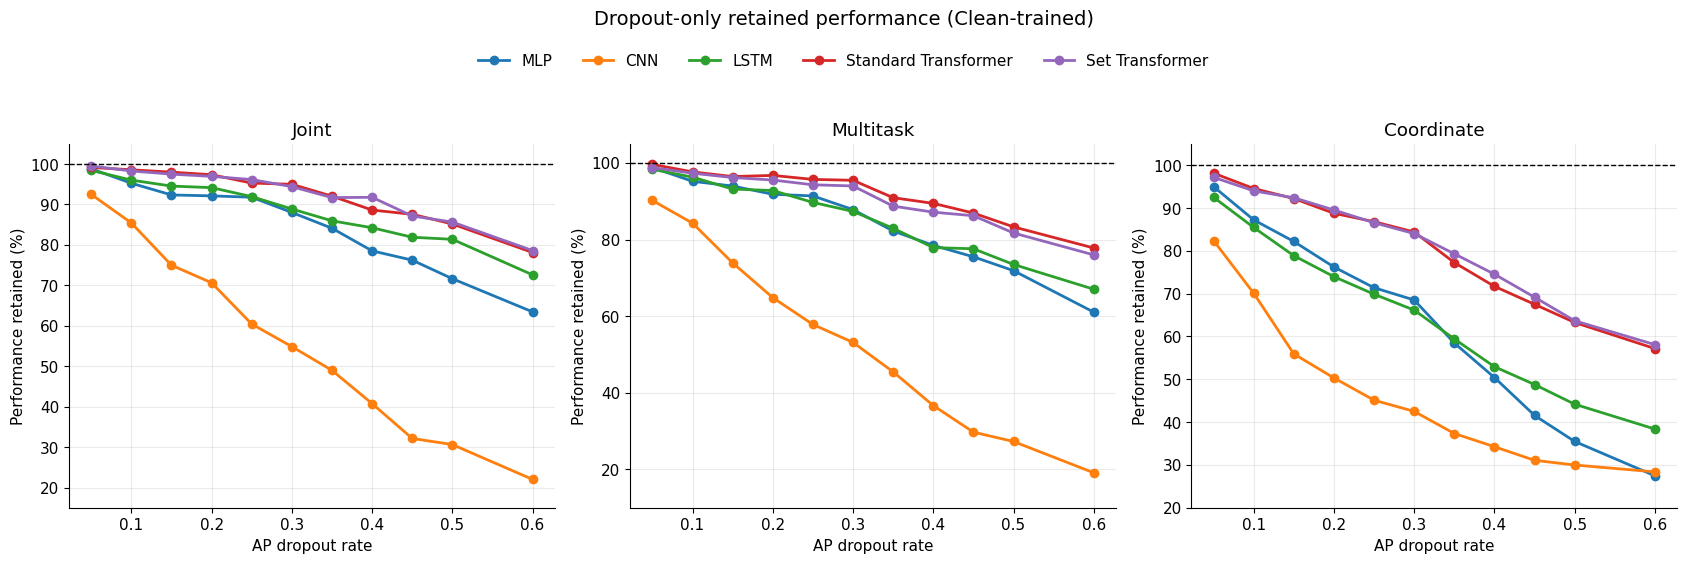

Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/special_retained_heatmap_clean_train.png
Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/special_retained_heatmap_clean_train.pdf


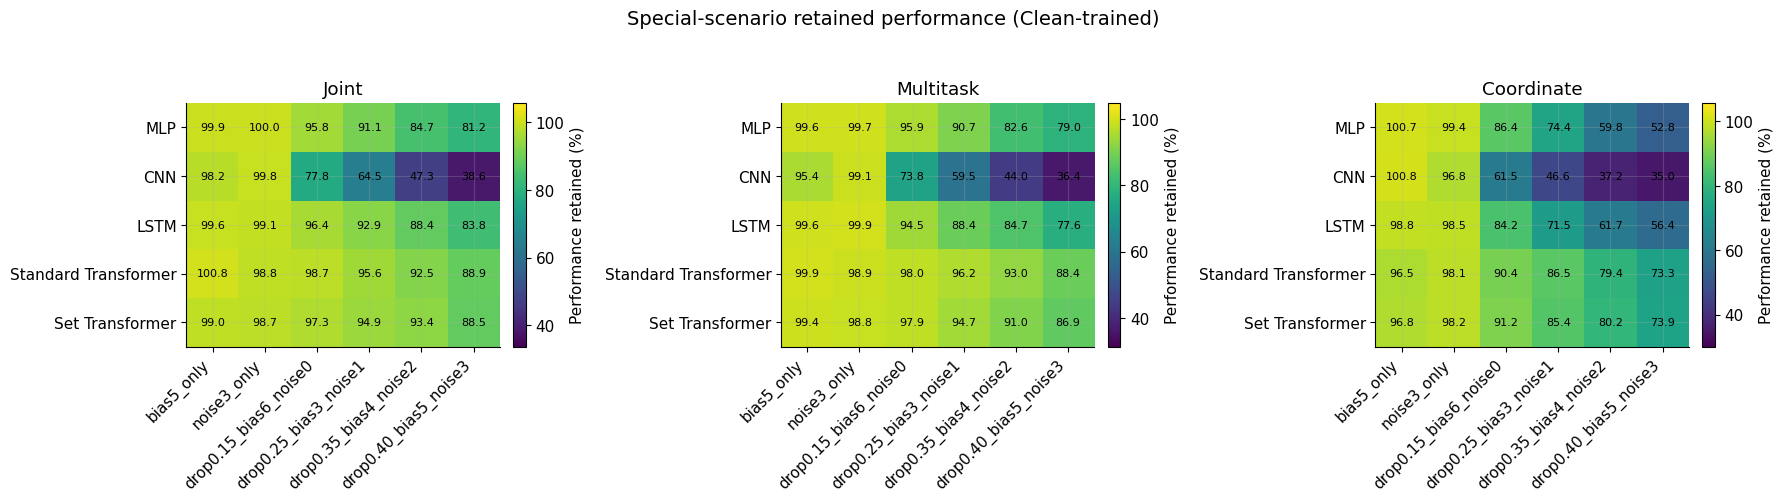

Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/dropout_retained_aug_train.png
Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/dropout_retained_aug_train.pdf


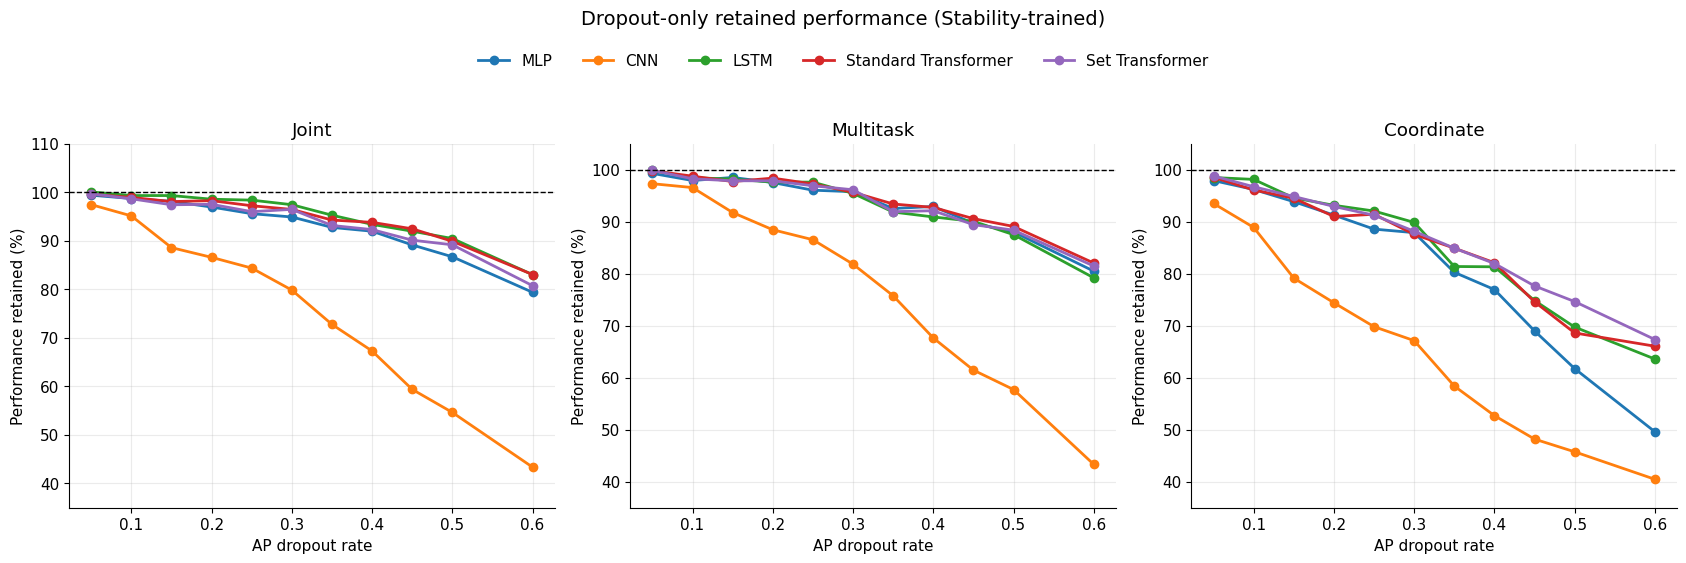

Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/special_retained_heatmap_aug_train.png
Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/special_retained_heatmap_aug_train.pdf


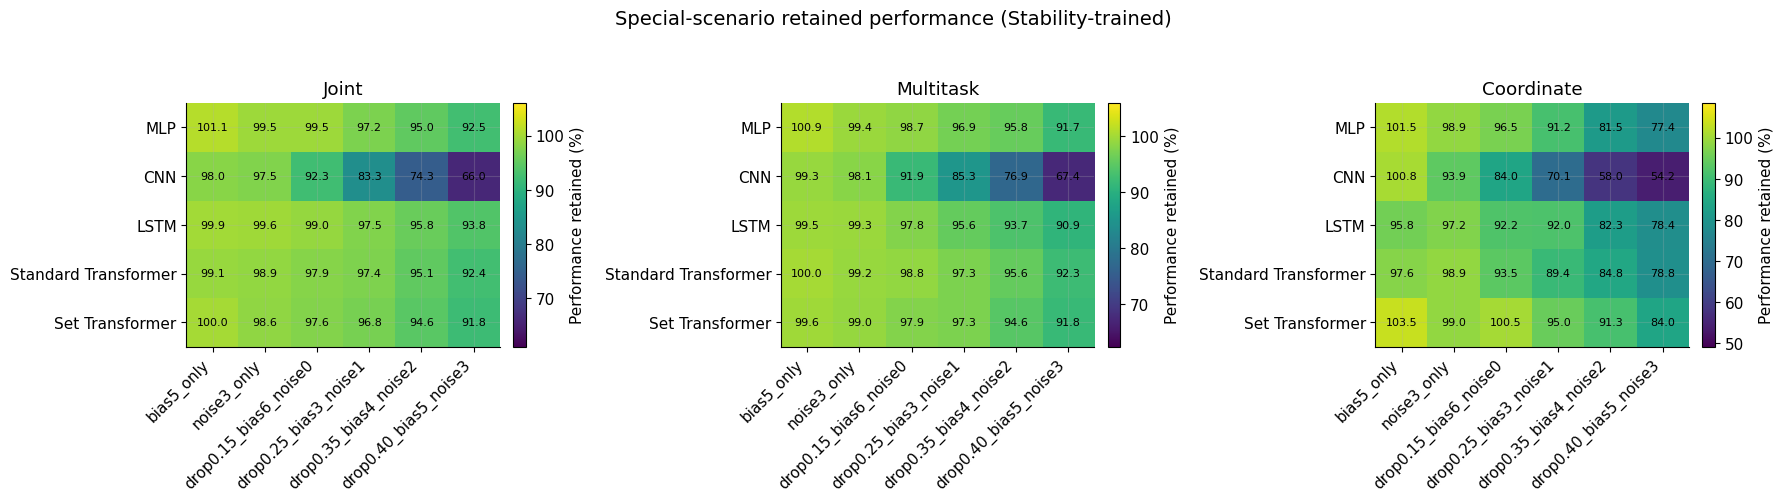

Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/stability_retained_compare_dropout_0.40.png
Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/stability_retained_compare_dropout_0.40.pdf


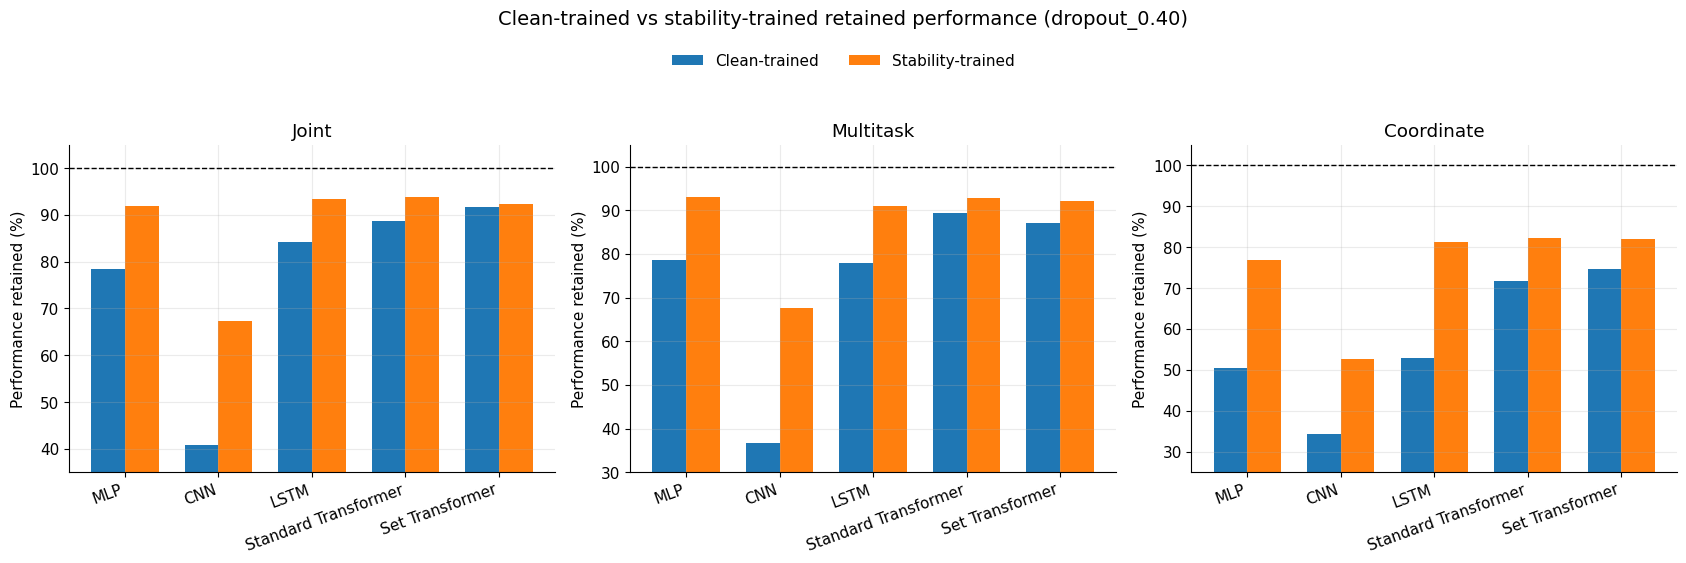

Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/stability_retained_compare_drop0.40_bias5_noise3.png
Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/stability_retained_compare_drop0.40_bias5_noise3.pdf


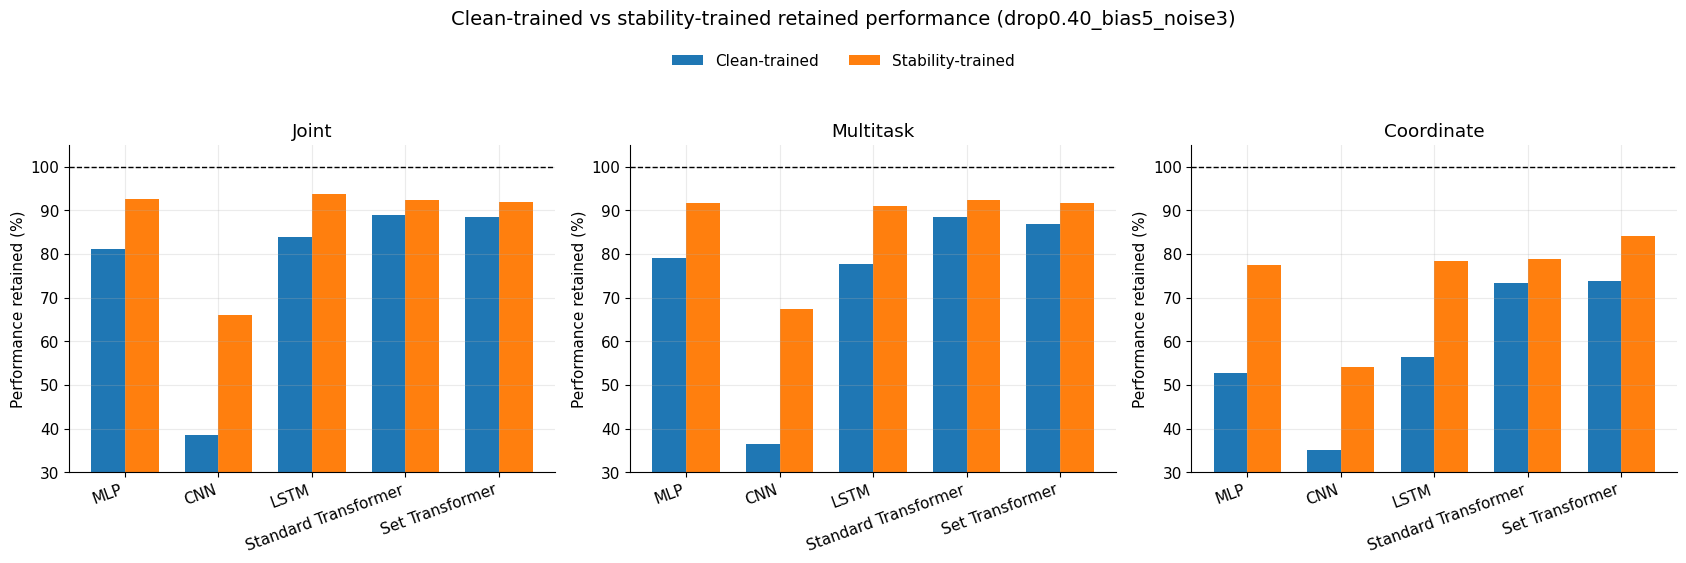

Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/stability_retained_compare_bias5_only.png
Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/stability_retained_compare_bias5_only.pdf


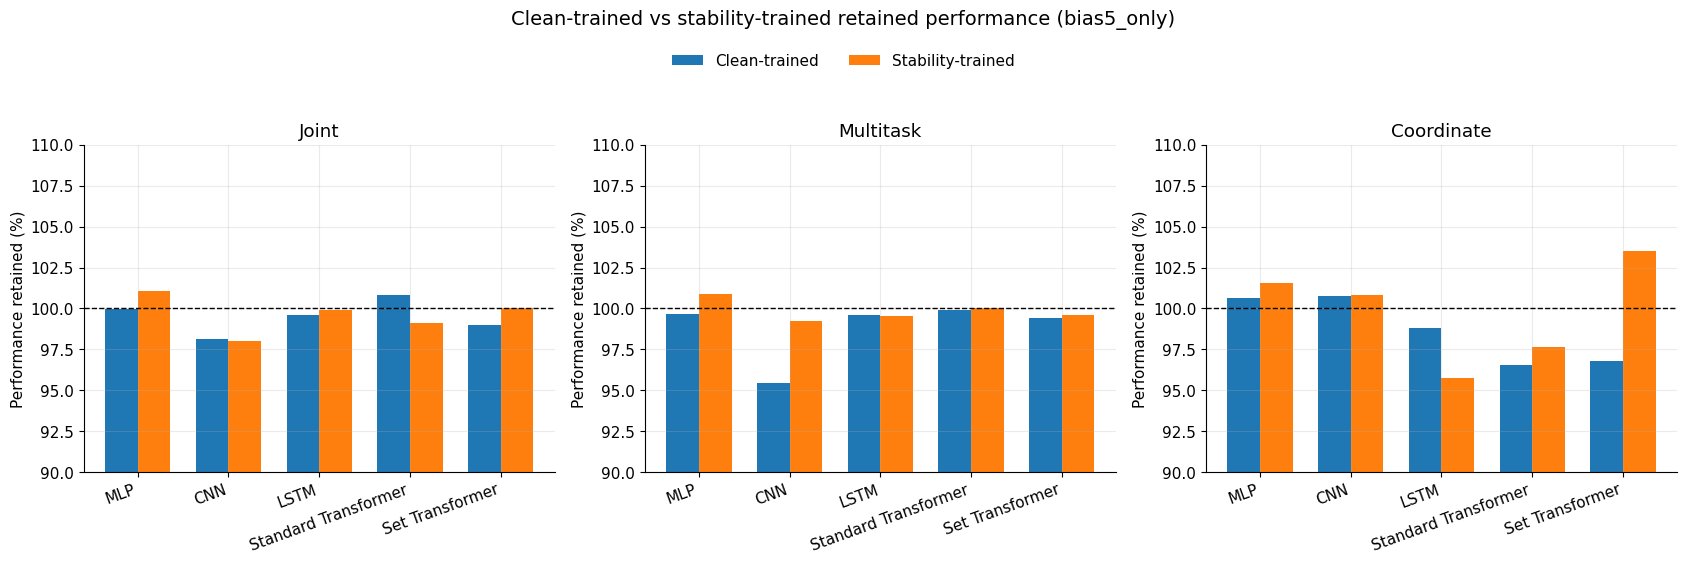

Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/stability_retained_compare_noise3_only.png
Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/stability_retained_compare_noise3_only.pdf


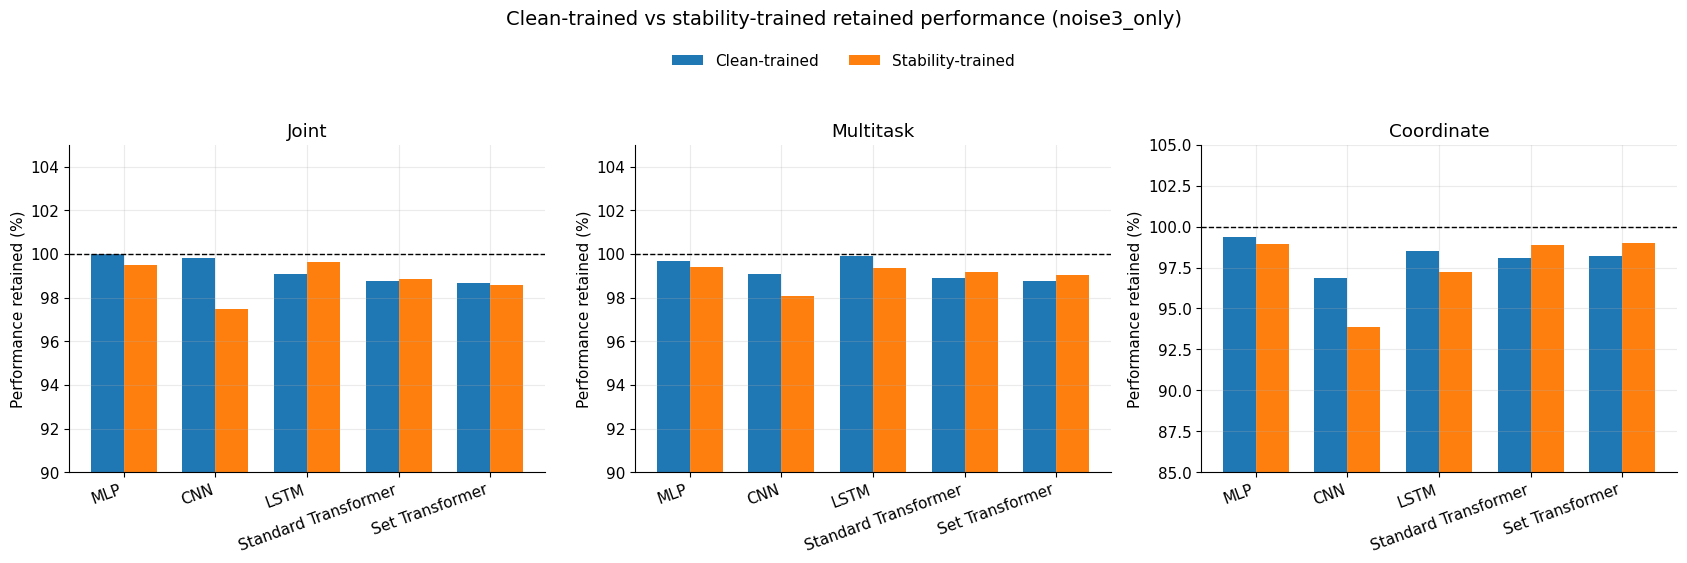

Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/deployability_final_score_vs_latency.png
Saved: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/deployability_final_score_vs_latency.pdf


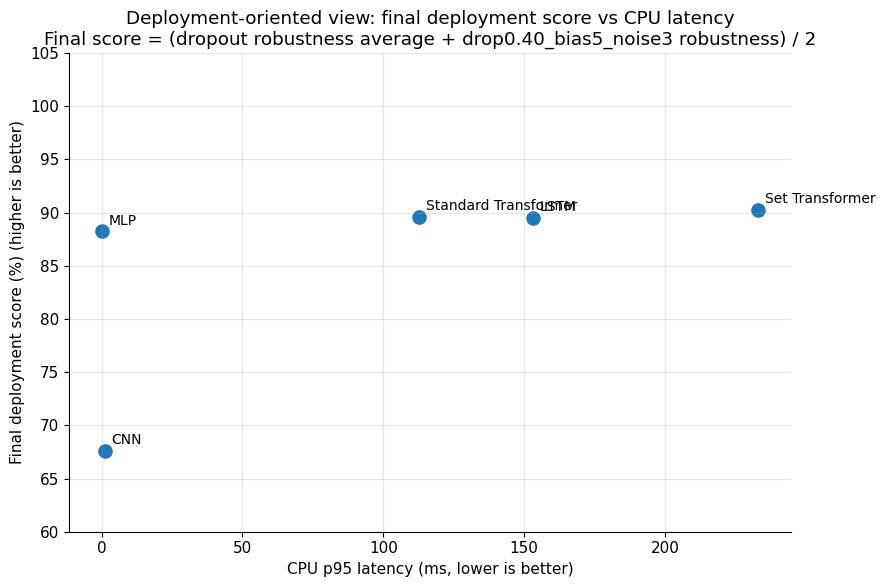

,Model,Dropout Robustness Avg (%),drop0.40_bias5_noise3 Robustness (%),Final Deployment Score (%),CPU p95 Latency (ms)
0,Set Transformer,91.253557,89.203539,90.228548,233.114643
1,Standard Transformer,91.319203,87.818659,89.568931,112.594001
2,LSTM,91.265463,87.715733,89.490598,152.990948
3,MLP,89.280715,87.178694,88.229705,0.165231
4,CNN,72.625046,62.554279,67.589663,1.072188


In [62]:
# Generate the updated figures.
if RETAINED_DF.empty:
    print('Skipping plots because no robustness/stability CSV data were loaded.')
else:
    if int(RETAINED_DF['is_suspicious_retained'].sum()) > 0:
        print(f"Dropping {int(RETAINED_DF['is_suspicious_retained'].sum())} suspicious retained rows from plots.")

    plot_dropout_retained(RETAINED_DF, 'clean_train')
    plot_special_retained_heatmaps(RETAINED_DF, 'clean_train')

    if (RETAINED_DF['regime'] == 'aug_train').any():
        plot_dropout_retained(RETAINED_DF, 'aug_train')
        plot_special_retained_heatmaps(RETAINED_DF, 'aug_train')
        plot_stability_retained_comparison(RETAINED_DF)

if 'FINAL_DEPLOYMENT_DF' in globals() and not FINAL_DEPLOYMENT_DF.empty:
    plot_final_deployment_score_df(FINAL_DEPLOYMENT_DF, scenario=DEPLOY_SCENARIO)
elif not RETAINED_DF.empty and not latency_table.empty:
    plot_final_deployment_score(RETAINED_DF, latency_table)


In [63]:
# ------------------------------------------------------------
# 2-row deployment comparison table
# Row 1 = CPU p95 latency
# Row 2 = Final deployment robustness score
# Columns = models
# ------------------------------------------------------------

if 'FINAL_DEPLOYMENT_DF' not in globals() or FINAL_DEPLOYMENT_DF.empty:
    raise ValueError("FINAL_DEPLOYMENT_DF is not available. Build it first.")

model_order_labels = [
    "MLP",
    "CNN",
    "LSTM",
    "Standard Transformer",
    "Set Transformer",
]

deploy_df = FINAL_DEPLOYMENT_DF.copy()

latency_row = (
    deploy_df.set_index("model_label")["cpu_p95_latency_ms"]
    .reindex(model_order_labels)
    .round(2)
)

robustness_row = (
    deploy_df.set_index("model_label")["final_deployment_score"]
    .reindex(model_order_labels)
    .round(2)
)

deployment_2row_table = pd.DataFrame(
    [latency_row, robustness_row],
    index=["CPU p95 latency (ms)", "Final deployment robustness score (%)"]
)

print("Deployment considerations")
display(deployment_2row_table)

Deployment considerations


model_label,MLP,CNN,LSTM,Standard Transformer,Set Transformer
CPU p95 latency (ms),0.17,1.07,152.99,112.59,233.11
Final deployment robustness score (%),88.23,67.59,89.49,89.57,90.23


Use this directly in the markdown cell, without a code fence:

$$
\text{Final Deployment Robustness Score} =
\frac{
\text{Dropout Robustness Average} + \text{Worst-Case Special Robustness}
}{2}
$$

$$
\text{Retained Performance (\%)} =
\begin{cases}
100 \cdot \dfrac{\text{Degraded Score}}{\text{Clean Score}}, & \text{classification} \\
100 \cdot \dfrac{\text{Clean Error}}{\text{Degraded Error}}, & \text{coordinate regression}
\end{cases}
$$



## 11. Export consolidated tables

In [64]:
# Save the consolidated tables so the paper / appendix workflow can reuse them.
exports = {}

if not shared_baseline_cfg.empty:
    p = OUTPUT_DIR / 'table_shared_baseline_config.csv'
    shared_baseline_cfg.to_csv(p, index=False)
    exports['shared_baseline_cfg'] = p

if not parameter_table.empty:
    p = OUTPUT_DIR / 'table_trainable_parameters.csv'
    parameter_table.to_csv(p, index=False)
    exports['parameter_table'] = p

if not tuned_params_table.empty:
    p = OUTPUT_DIR / 'table_tuned_parameters.csv'
    tuned_params_table.to_csv(p, index=False)
    exports['tuned_params_table'] = p

if not clean_table.empty:
    p = OUTPUT_DIR / 'table_clean_performance.csv'
    clean_table.to_csv(p, index=False)
    exports['clean_table'] = p

if not robustness_long.empty:
    p = OUTPUT_DIR / 'table_robustness_stability_long.csv'
    robustness_long.to_csv(p, index=False)
    exports['robustness_long'] = p

if not latency_table.empty:
    p = OUTPUT_DIR / 'table_latency.csv'
    latency_table.to_csv(p, index=False)
    exports['latency_table'] = p

print('Saved exports:')
for k, v in exports.items():
    print(f'  {k}: {v}')

Saved exports:
  shared_baseline_cfg: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/table_shared_baseline_config.csv
  parameter_table: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/table_trainable_parameters.csv
  tuned_params_table: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/table_tuned_parameters.csv
  clean_table: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/table_clean_performance.csv
  robustness_long: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/table_robustness_stability_long.csv
  latency_table: /storage/ice1/7/5/kw53/cs7643/tmp/CS7643-Project/results/table_latency.csv


## Notes

- If the tuned-parameter section is empty, stop guessing. Export a best-trial CSV from each tuning notebook.
- If robustness/stability is empty, the degradation notebooks need to write a long-format CSV.
- The damage-based plots are the right direction for the paper because they unify interpretation across tasks.
- The deployment scatter is deliberately simple. It is not a replacement for the full tables. It is a summary view.